# TASK 1.1

In [1]:
import pandas as pd
import numpy as np
import sqlite3
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
training_data = pd.read_csv('train.csv')
ideal_functions_data = pd.read_csv('ideal.csv')
test_data = pd.read_csv('test.csv')

In [3]:
training_data.head()

,x,y1,y2,y3,y4
0,-20.0,39.778572,-40.078590,-20.214268,-0.324914
1,-19.9,39.604813,-39.784000,-20.070950,-0.058820
2,-19.8,40.099070,-40.018845,-19.906782,-0.451830
3,-19.7,40.151100,-39.518402,-19.389118,-0.612044
4,-19.6,39.795662,-39.360065,-19.815890,-0.306076


In [4]:
ideal_functions_data.head()

,x,y1,y2,y3,y4,y5,y6,y7,y8,y9,...,y41,y42,y43,y44,y45,y46,y47,y48,y49,y50
0,-20.0,-0.912945,0.408082,9.087055,5.408082,-9.087055,0.912945,-0.839071,-0.850919,0.816164,...,-40.456474,40.204040,2.995732,-0.008333,12.995732,5.298317,-5.298317,-0.186278,0.912945,0.396850
1,-19.9,-0.867644,0.497186,9.132356,5.497186,-9.132356,0.867644,-0.865213,0.168518,0.994372,...,-40.233820,40.048590,2.990720,-0.008340,12.990720,5.293305,-5.293305,-0.215690,0.867644,0.476954
2,-19.8,-0.813674,0.581322,9.186326,5.581322,-9.186326,0.813674,-0.889191,0.612391,1.162644,...,-40.006836,39.890660,2.985682,-0.008347,12.985682,5.288267,-5.288267,-0.236503,0.813674,0.549129
3,-19.7,-0.751573,0.659649,9.248426,5.659649,-9.248426,0.751573,-0.910947,-0.994669,1.319299,...,-39.775787,39.729824,2.980619,-0.008354,12.980619,5.283204,-5.283204,-0.247887,0.751573,0.612840
4,-19.6,-0.681964,0.731386,9.318036,5.731386,-9.318036,0.681964,-0.930426,0.774356,1.462772,...,-39.540980,39.565693,2.975530,-0.008361,12.975530,5.278115,-5.278115,-0.249389,0.681964,0.667902


In [5]:
test_data.head()

,x,y
0,17.5,34.161040
1,0.3,1.215102
2,-8.7,-16.843908
3,-19.2,-37.170870
4,-11.0,-20.263054


### Function to calculate the sum of squared deviations (Least Squares Criterion)

In [6]:
def least_squares_deviation(training_data, ideal_function_data):
    squared_deviations = (training_data - ideal_function_data) ** 2
    return squared_deviations.sum()

### Function to choose the best ideal functions based on least square deviations

In [7]:
def choose_best_ideal_functions(training_data, ideal_functions_data):
    best_functions = []
    for i in range(1, 5):  
        training_func = training_data[f'y{i}']
        best_fit_function = None
        min_deviation = float('inf')
        for j in range(1, 51):  
            ideal_func = ideal_functions_data[f'y{j}']
            deviation = least_squares_deviation(training_func, ideal_func)
            if deviation < min_deviation:
                min_deviation = deviation
                best_fit_function = j
        best_functions.append(best_fit_function)  #
    return best_functions

In [8]:
best_functions = choose_best_ideal_functions(training_data, ideal_functions_data)

In [9]:
print("Best Ideal Functions for each Training Dataset:")
for i, func in enumerate(best_functions, start=1):
    print(f"Training Function Y{i} is best fit by Ideal Function Y{func}")

Best Ideal Functions for each Training Dataset:
Training Function Y1 is best fit by Ideal Function Y42
Training Function Y2 is best fit by Ideal Function Y41
Training Function Y3 is best fit by Ideal Function Y11
Training Function Y4 is best fit by Ideal Function Y48


#### Visualizing the Training Data vs. Ideal Functions

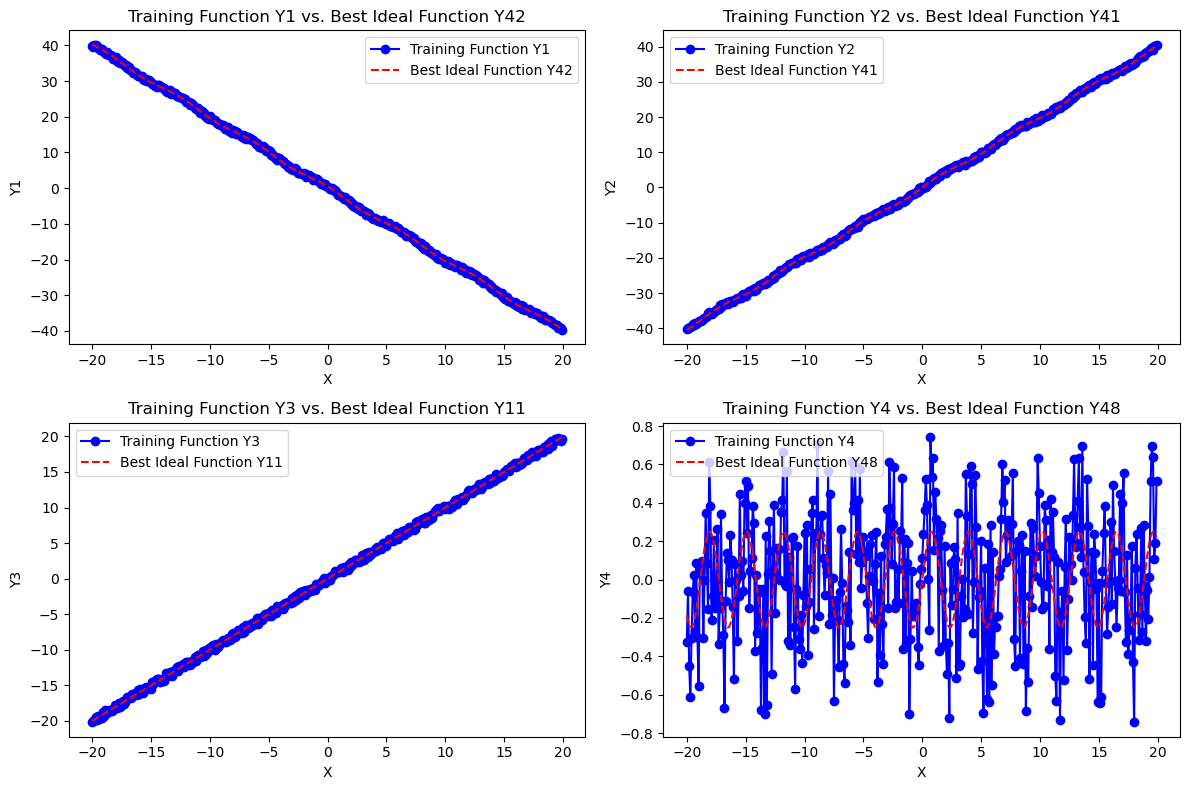

In [10]:
def visualize_training_data(training_data, ideal_functions_data, best_functions):
    plt.figure(figsize=(12, 8))
    for i in range(1, 5):
        plt.subplot(2, 2, i)
        plt.plot(training_data['x'], training_data[f'y{i}'], label=f'Training Function Y{i}', color='blue', marker='o')
        best_ideal_func = best_functions[i - 1]
        plt.plot(ideal_functions_data['x'], ideal_functions_data[f'y{best_ideal_func}'], label=f'Best Ideal Function Y{best_ideal_func}', color='red', linestyle='--')
        plt.xlabel('X')
        plt.ylabel(f'Y{i}')
        plt.title(f'Training Function Y{i} vs. Best Ideal Function Y{best_ideal_func}')
        plt.legend()
        
    plt.tight_layout()
    plt.show()

visualize_training_data(training_data, ideal_functions_data, best_functions)

#### Visualizing the Test Data and Deviations

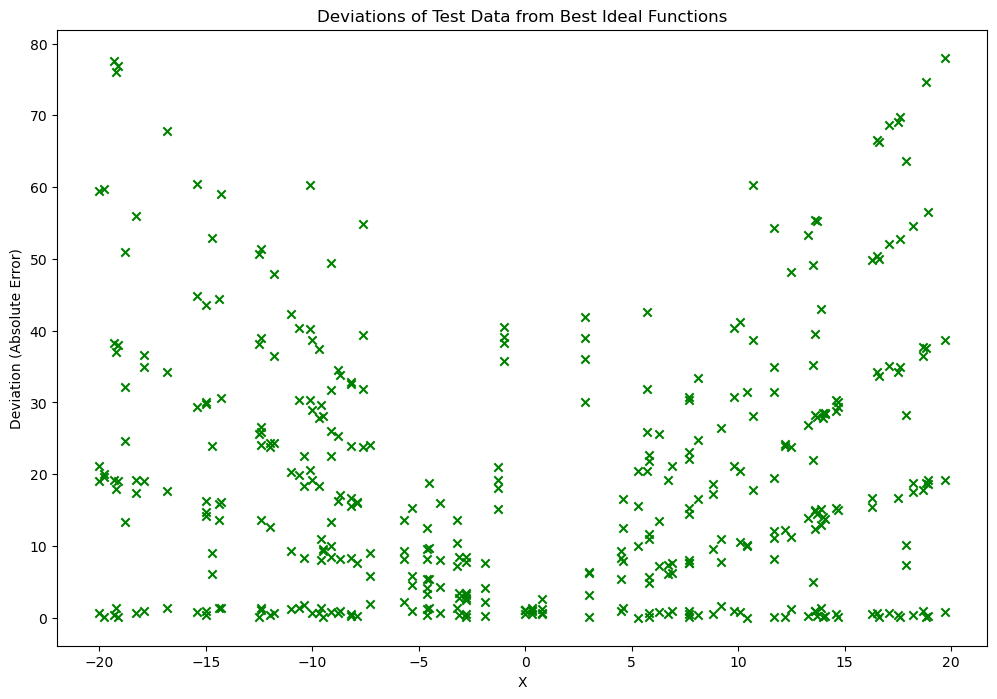

In [11]:
def visualize_deviations(test_data, ideal_functions_data, best_functions):
    plt.figure(figsize=(12, 8))
    
    for i, test_row in test_data.iterrows():
        x_value = test_row['x']
        y_value = test_row['y']
        
        deviations = []
        for j, best_func in enumerate(best_functions):
            ideal_values = ideal_functions_data[ideal_functions_data['x'] == x_value][f'y{best_func}'].values
            if len(ideal_values) > 0:
                ideal_value = ideal_values[0]
                deviation = abs(ideal_value - y_value)
                deviations.append(deviation)
        
        plt.scatter([x_value]*4, deviations, color='green', marker='x')
    
    plt.xlabel('X')
    plt.ylabel('Deviation (Absolute Error)')
    plt.title('Deviations of Test Data from Best Ideal Functions')
    plt.show()


visualize_deviations(test_data, ideal_functions_data, best_functions)

# Task 2

### Save the result to a database

#### Connect to SQLite database

In [12]:
engine = create_engine('sqlite:///function.db')
conn = engine.connect()

In [13]:
training_data.to_sql('training_data', conn, if_exists='replace', index=False)

400

In [14]:
ideal_functions_data.to_sql('ideal_functions', conn, if_exists='replace', index=False)

400

In [15]:
best_functions_df = pd.DataFrame({
    'Training Function': [f'y{i}' for i in range(1, 5)],
    'Best Ideal Function': [f'y{func}' for func in best_functions]
})

In [16]:
best_functions_df.to_sql('best_functions', conn, if_exists='replace', index=False)

4

#### Training data from the database

In [17]:
print("\nTraining Data from Database:")
training_data_from_db = pd.read_sql('SELECT * FROM training_data', conn)
print(training_data_from_db.head(), "\n")


Training Data from Database:
      x         y1         y2         y3        y4
0 -20.0  39.778572 -40.078590 -20.214268 -0.324914
1 -19.9  39.604813 -39.784000 -20.070950 -0.058820
2 -19.8  40.099070 -40.018845 -19.906782 -0.451830
3 -19.7  40.151100 -39.518402 -19.389118 -0.612044
4 -19.6  39.795662 -39.360065 -19.815890 -0.306076 



#### The ideal functions data from the database

In [18]:
print("Ideal Functions Data from Database:")
ideal_functions_from_db = pd.read_sql('SELECT * FROM ideal_functions', conn)
ideal_functions_from_db.head()

Ideal Functions Data from Database:


,x,y1,y2,y3,y4,y5,y6,y7,y8,y9,...,y41,y42,y43,y44,y45,y46,y47,y48,y49,y50
0,-20.0,-0.912945,0.408082,9.087055,5.408082,-9.087055,0.912945,-0.839071,-0.850919,0.816164,...,-40.456474,40.204040,2.995732,-0.008333,12.995732,5.298317,-5.298317,-0.186278,0.912945,0.396850
1,-19.9,-0.867644,0.497186,9.132356,5.497186,-9.132356,0.867644,-0.865213,0.168518,0.994372,...,-40.233820,40.048590,2.990720,-0.008340,12.990720,5.293305,-5.293305,-0.215690,0.867644,0.476954
2,-19.8,-0.813674,0.581322,9.186326,5.581322,-9.186326,0.813674,-0.889191,0.612391,1.162644,...,-40.006836,39.890660,2.985682,-0.008347,12.985682,5.288267,-5.288267,-0.236503,0.813674,0.549129
3,-19.7,-0.751573,0.659649,9.248426,5.659649,-9.248426,0.751573,-0.910947,-0.994669,1.319299,...,-39.775787,39.729824,2.980619,-0.008354,12.980619,5.283204,-5.283204,-0.247887,0.751573,0.612840
4,-19.6,-0.681964,0.731386,9.318036,5.731386,-9.318036,0.681964,-0.930426,0.774356,1.462772,...,-39.540980,39.565693,2.975530,-0.008361,12.975530,5.278115,-5.278115,-0.249389,0.681964,0.667902


In [19]:
print("Best Functions Mapping from Database:")
best_functions_from_db = pd.read_sql('SELECT * FROM best_functions', conn)
print(best_functions_from_db, "\n")

Best Functions Mapping from Database:
  Training Function Best Ideal Function
0                y1                 y42
1                y2                 y41
2                y3                 y11
3                y4                 y48 



### Calculate Deviations Between Test Data and Best Ideal Functions

In [20]:
def calculate_deviation(test_data, ideal_functions_data, best_functions):
    deviations = []
    
    for index, row in test_data.iterrows():
        x_value = row['x']
        y_value_test = row['y']
        
        
        best_function_index = best_functions[int(index % 4)] - 1 
        y_value_ideal = ideal_functions_data.loc[ideal_functions_data['x'] == x_value, f'y{best_function_index + 1}'].values[0]
        
        
        deviation = abs(y_value_test - y_value_ideal)
        deviations.append([x_value, y_value_test, y_value_ideal, deviation])
    
    return deviations

In [21]:
deviation_results = calculate_deviation(test_data, ideal_functions_data, best_functions)

In [22]:
deviation_df = pd.DataFrame(deviation_results, columns=['X', 'Y (test func)', 'Y (ideal func)', 'Delta Y'])

In [23]:
deviation_df.to_sql('deviation_results', conn, if_exists='replace', index=False)

100

In [24]:
print("Deviation Results Saved to Database")

Deviation Results Saved to Database


In [25]:
saved_data = pd.read_sql('SELECT * FROM deviation_results', conn)
print(saved_data.head()) 

      X  Y (test func)  Y (ideal func)    Delta Y
0  17.5      34.161040      -34.890280  69.051320
1   0.3       1.215102        0.747760   0.467342
2  -8.7     -16.843908       -8.700000   8.143908
3 -19.2     -37.170870       -0.161224  37.009646
4 -11.0     -20.263054       22.002213  42.265267


### Visualizing the Deviation

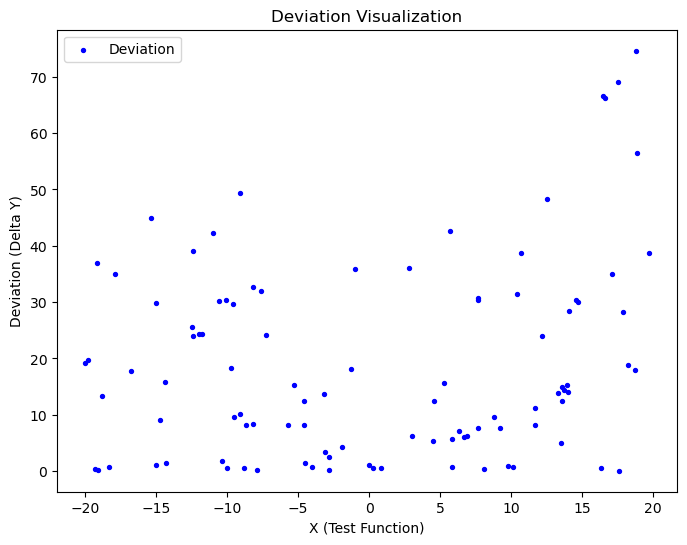

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(deviation_df['X'], deviation_df['Delta Y'], color='blue', label='Deviation', s=8)
plt.xlabel('X (Test Function)')
plt.ylabel('Deviation (Delta Y)')
plt.title('Deviation Visualization')
plt.legend()
plt.show()

### Unit Testing

In [27]:
import unittest

In [28]:
def calculate_deviation(test_data, ideal_data, best_functions):
    deviations = []
    for i, row in test_data.iterrows():
        x = row['x']
        y = row['y']
        best_func_index = best_functions[i] - 1  
        ideal_y = ideal_data.iloc[i, best_func_index + 1]  
        deviation = y - ideal_y
        deviations.append((x, y, ideal_y, deviation))
    return deviations

In [29]:
class TestDeviationCalculator(unittest.TestCase):
    def test_calculate_deviation(self):
        test_data = pd.DataFrame({
            'x': [1, 2],
            'y': [10, 15]
        })
        
        ideal_data = pd.DataFrame({
            'x': [1, 2],
            'y1': [9, 14],
            'y2': [8, 13]
        })
        
        best_functions = [1, 1] 
        deviations = calculate_deviation(test_data, ideal_data, best_functions)
        
        
        self.assertEqual(deviations[0][3], 1) 
        self.assertEqual(deviations[1][3], 1)  
        
if __name__ == '__main__':
    unittest.TextTestRunner().run(unittest.TestLoader().loadTestsFromTestCase(TestDeviationCalculator))

.
----------------------------------------------------------------------
Ran 1 test in 0.005s

OK
